In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/extrovert-vs-introvert-behavior-data/personality_datasert.csv')
df 

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
...,...,...,...,...,...,...,...,...
2895,3.0,No,7.0,6.0,No,6.0,6.0,Extrovert
2896,3.0,No,8.0,3.0,No,14.0,9.0,Extrovert
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,Introvert
2898,11.0,Yes,1.0,3.0,Yes,2.0,0.0,Introvert


In [3]:
df.columns = [col.lower() for col in df.columns]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   time_spent_alone           2900 non-null   float64
 1   stage_fear                 2900 non-null   object 
 2   social_event_attendance    2900 non-null   float64
 3   going_outside              2900 non-null   float64
 4   drained_after_socializing  2900 non-null   object 
 5   friends_circle_size        2900 non-null   float64
 6   post_frequency             2900 non-null   float64
 7   personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [5]:
df.describe()

,time_spent_alone,social_event_attendance,going_outside,friends_circle_size,post_frequency
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.441180,2.872608,2.221597,4.232340,2.893587
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.963354,3.000000,5.000000,3.000000
75%,7.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


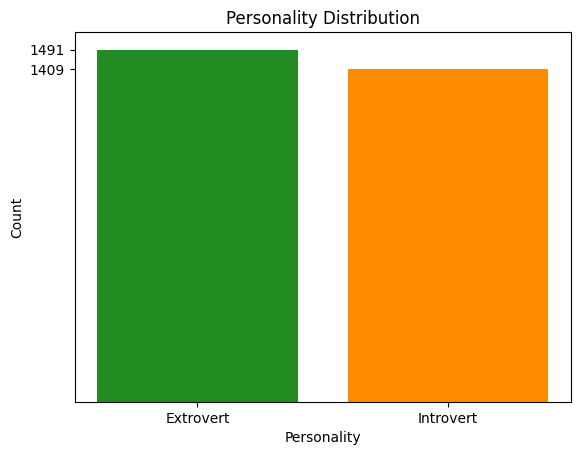

In [6]:

counts = df['personality'].value_counts()

plt.bar(counts.index, counts.values,color=['forestgreen', 'darkorange'])
plt.title('Personality Distribution')
plt.xlabel('Personality')
plt.ylabel('Count')
plt.yticks(counts.values)
plt.show()

In [7]:
numeric_cols = df.select_dtypes(include='number').columns
non_numeric_cols = df.select_dtypes(exclude='number').columns

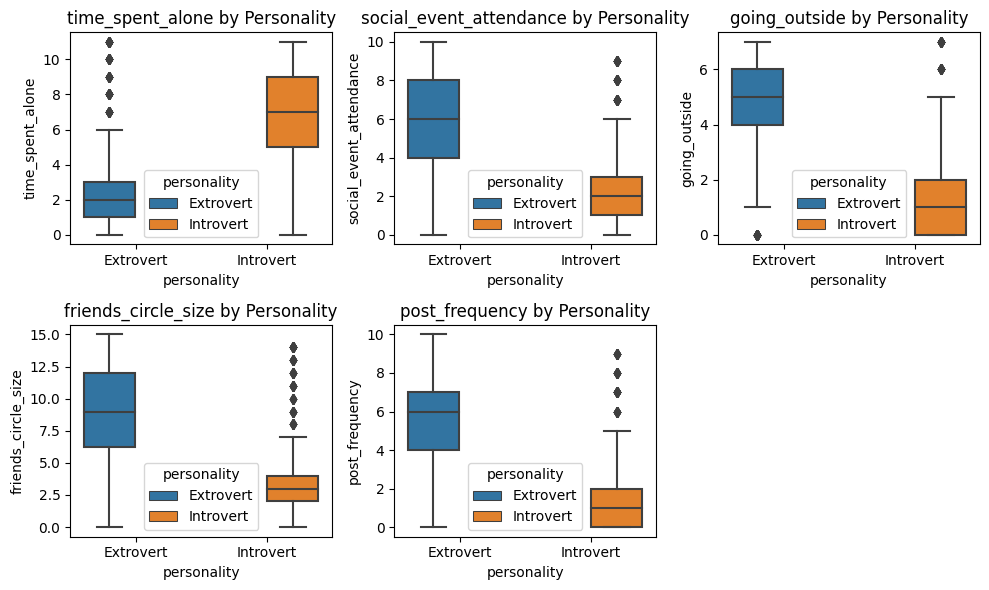

In [8]:

plt.figure(figsize=(10, 6))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='personality', y=col, data=df,hue='personality')
    plt.title(f'{col} by Personality')

plt.tight_layout()
plt.show()


In [9]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()
df['stage_fear'] = encode.fit_transform(df['stage_fear'])
df['drained_after_socializing'] = encode.fit_transform(df['drained_after_socializing'])

label_mapping = {'Introvert': 0,
                  'Extrovert': 1}
df['personality_encoded'] = df['personality'].map(label_mapping)


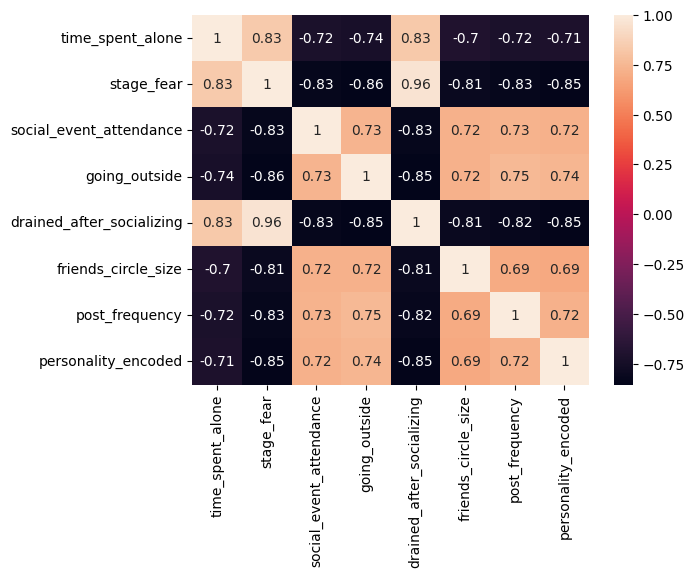

In [10]:
corr_mat = df.drop(columns='personality').corr()
sns.heatmap(corr_mat, annot=True)
plt.show()


In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['personality','personality_encoded']),
                                                    df['personality_encoded'], test_size=.20,random_state=42)

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

param_grid  = {
    'max_depth':[None, 5, 10,20,50,100],
    'min_samples_split':[2,5,10,20],
    'max_features':[None,4,5,6]
}

gd = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    cv = 5,
    scoring='accuracy',
    n_jobs=-1
)

gd.fit(x_train, y_train)
best_dt = gd.best_estimator_
best_dt

DecisionTreeClassifier(max_depth=5, max_features=4)

Decission Tree Accuracy: 0.9293103448275862
                  Predicted Introvert  Predicted Extrovert
Actual Introvert                  261                   17
Actual Extrovert                   24                  278


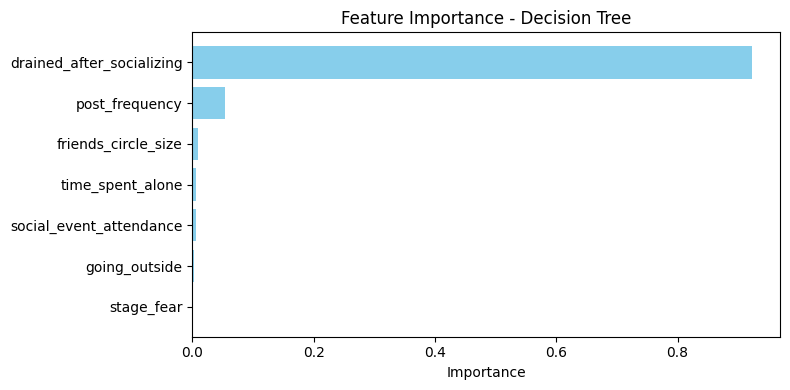

In [13]:

dt_pred = best_dt.predict(x_test)

accuracy_dt = accuracy_score(y_test,dt_pred)
precision_dt = precision_score(y_test,dt_pred)
recall_dt = recall_score(y_test,dt_pred)

print('Decission Tree Accuracy:',accuracy_dt)



cm = confusion_matrix(y_test, dt_pred)

class_names = ['Introvert', 'Extrovert']

cm_df = pd.DataFrame(cm,
    index=[f'Actual {name}' for name in class_names],
    columns=[f'Predicted {name}' for name in class_names])
print(cm_df)


feature_names = x_train.columns
importances = best_dt.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Importance') 
plt.title('Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()


In [14]:
from sklearn.svm import SVC
svc = SVC()
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf','sigmoid'],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
                estimator=SVC(),
                param_grid = param_grid,
                cv=5,
                scoring='accuracy')

grid.fit(x_train, y_train)
best_svc = grid.best_estimator_

svc_pred = best_svc.predict(x_test)

accuracy_svc = accuracy_score(y_test,svc_pred)
precision_svc = precision_score(y_test,svc_pred)
recall_svc = recall_score(y_test,svc_pred)
print('SVC Accuracy:',accuracy_svc)

cm = confusion_matrix(y_test, svc_pred)

class_names = ['Introvert', 'Extrovert']

cm_svc = pd.DataFrame(cm,
    index=[f'Actual {name}' for name in class_names],
    columns=[f'Predicted {name}' for name in class_names])
print(cm_svc)

SVC Accuracy: 0.9293103448275862
                  Predicted Introvert  Predicted Extrovert
Actual Introvert                  261                   17
Actual Extrovert                   24                  278


In [15]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb.fit(x_train, y_train)
nb_pred = nb.predict(x_test)
accuracy_nb = accuracy_score(y_test, nb_pred)
precision_nb = precision_score(y_test,nb_pred)
recall_nb = recall_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", accuracy_nb)

cm = confusion_matrix(y_test, nb_pred)

class_names = ['Introvert', 'Extrovert']

cm_nb = pd.DataFrame(cm,
    index=[f'Actual {name}' for name in class_names],
    columns=[f'Predicted {name}' for name in class_names])
print(cm_nb)

Naive Bayes Accuracy: 0.9293103448275862
                  Predicted Introvert  Predicted Extrovert
Actual Introvert                  261                   17
Actual Extrovert                   24                  278


In [16]:

from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train) 

print("Best Params:", grid.best_params_)

best_gb = grid.best_estimator_
gb_pred = best_gb.predict(x_test)

accuracy_gb = accuracy_score(y_test,gb_pred)
precision_gb = precision_score(y_test,gb_pred)
recall_gb = recall_score(y_test, gb_pred)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

cm = confusion_matrix(y_test, gb_pred)

class_names = ['Introvert', 'Extrovert']

cm_gb = pd.DataFrame(cm,
    index=[f'Actual {name}' for name in class_names],
    columns=[f'Predicted {name}' for name in class_names])
print(cm_gb)


Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Gradient Boosting Accuracy: 0.9293103448275862
                  Predicted Introvert  Predicted Extrovert
Actual Introvert                  261                   17
Actual Extrovert                   24                  278


In [17]:
res = pd.DataFrame({
    "Metric": ["Accuracy", "Precission", 'Recall'],
    "Decision Tree": [ accuracy_dt,precision_dt,recall_dt],
    "SVC" : [accuracy_svc, precision_svc,recall_svc],
    "Naive Bayes" : [accuracy_nb,precision_nb,recall_nb],
    "Gradient Boosting": [accuracy_gb,precision_gb,recall_gb]
})
print(res)

       Metric  Decision Tree       SVC  Naive Bayes  Gradient Boosting
0    Accuracy       0.929310  0.929310     0.929310           0.929310
1  Precission       0.942373  0.942373     0.942373           0.942373
2      Recall       0.920530  0.920530     0.920530           0.920530
